In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import multiprocessing as mp

import os
import re
import itertools
import pickle
import json
import datetime

from joblib import Parallel, delayed
from tqdm.notebook import tqdm
from collections import defaultdict
from multiprocess import Pool
from scipy import sparse
from scipy.sparse import linalg
from itertools import islice
from networkx.readwrite import json_graph

## Load interactions

In [2]:
df_int = pd.read_csv("../../dataset/final_dataset/contacted_anon.csv")

# Only keep vacancies with at least 15 interactions
relevant_vacancies = df_int["cvid"].value_counts()[df_int["cvid"].value_counts() >= 15].index

# Filter to only relevant vacancies
df_int = df_int[df_int["cvid"].isin(relevant_vacancies.values)][["humanjobid", "response", "cvid"]].fillna(0)

### TODO: TRY WHAT HAPPENS WHEN WE ONLY USE ACTUAL 1S
strict = True

if strict:
    df_int["response"] = df_int["response"].apply(lambda x: 1 if "ok" in str(x) else 0)
else:
    df_int["response"] = df_int["response"].apply(lambda x: x if x == 0 else 1)

non_zero = df_int.groupby("cvid")["response"].sum() > 0
non_zero = set(non_zero[non_zero == True].index)
len(non_zero), len(df_int.groupby("cvid"))

df_graphs = df_int[df_int["cvid"].isin(non_zero)]
df_bridges = pd.read_excel("../outputs/final_outputs/bridges.xlsx")

In [3]:
target_cols = df_bridges.filter(like='bridges').columns
df_bridges[target_cols] = df_bridges[target_cols].replace("[]", np.nan)
df_bridges = df_bridges.dropna(subset=target_cols, how='all')

todo = df_bridges[["humanjobid", "cvid"]].values
len(todo)

19129

## Load KG

In [4]:
def load_KG(model, prompt, isco=False):

    G = nx.DiGraph()

    print("Loading", model, prompt, isco)    

    if isco:
        filename = f"../outputs/inferred_outputs/kg_{model}_{prompt}_isco.edgelist"
    else:
        filename = f"../outputs/inferred_outputs/kg_{model}_{prompt}.edgelist"
    
    with open(filename, encoding="utf-8") as f:
        for line in tqdm(f.readlines()):
            
            if "err:error" in line:
                print(line)
                continue
                
            s, p, o = eval(line)
            G.add_edge(s, o, edge_type=p)
    
    # Find neighbors of each node (for quicker retrieval later on) 
    all_neighbors = {}
    
    H = G.to_undirected()
    
    for n in tqdm(G.nodes):
        all_neighbors[n] = set(H.neighbors(n))
        
    all_neighbors = {k: {i for i in v if not pd.isna(i)} for k, v in all_neighbors.items()}
    
    # Do this once, outside your pair-loop
    degrees = dict(H.degree())
    weights = {}
    
    for u, v in H.edges():
        # Pre-calculating degrees into a dict is much faster than calling H.degree(u)
        weights[(u, v)] = 1.0 / np.log1p(degrees[u] + degrees[v])
    
    nx.set_edge_attributes(H, weights, 'ppr_weight')

    return G

# BFS

In [5]:
def extract_subgraphs(G_original, H, H_safe, node_to_comp_H, degrees, source, target):
    null_metrics = {
        "path_exists": False, "num_nodes": 0, "num_edges": 0,
        "density": 0.0, "avg_degree": 0.0, "avg_clustering": 0.0,
        "shortest_path_length": -1
    }

    if source not in H or target not in H: return None, null_metrics
    if node_to_comp_H.get(source) != node_to_comp_H.get(target): return None, null_metrics
    if source == target: return None, null_metrics
        
    final_nodes = {source, target}
    
    try:
        # Main Spine Routing
        try:
            spine_path = nx.bidirectional_shortest_path(H_safe, source, target)
        except (nx.NetworkXNoPath, nx.NodeNotFound):
            spine_path = nx.bidirectional_shortest_path(H, source, target)
            
        final_nodes.update(spine_path)
        
        # GNN Multi-Path Extraction (Fast Set Intersections)
        S_neighbors = set(H[source])
        T_neighbors = set(H[target])
        
        # 2-hop paths (Candidate -> Shared Entity <- Vacancy)
        common_2hop = S_neighbors.intersection(T_neighbors)
        final_nodes.update(list(common_2hop)[:25]) 
        
        # 3-hop paths (Candidate -> Entity A -> Entity B <- Vacancy)
        S_safe_neighbors = {n for n in S_neighbors if degrees.get(n, 0) < 1500}
        T_safe_neighbors = {n for n in T_neighbors if degrees.get(n, 0) < 1500}
        
        for s_n in S_safe_neighbors:
            s_n_neighbors = set(H[s_n])
            bridge_nodes = s_n_neighbors.intersection(T_safe_neighbors)
            if bridge_nodes:
                final_nodes.add(s_n)
                final_nodes.update(list(bridge_nodes)[:5])

        # Aggressively cap exploration to prevent RAM/time explosion
        S_ultra_safe = list({n for n in S_neighbors if degrees.get(n, 0) < 200})[:25]
        T_ultra_safe = list({n for n in T_neighbors if degrees.get(n, 0) < 200})[:25]
        
        for s_n in S_ultra_safe:
            A_neighbors = set(H[s_n])
            for t_n in T_ultra_safe:
                C_neighbors = set(H[t_n])
                
                # Find 'B' nodes that connect 'A' and 'C'
                bridge_B_nodes = A_neighbors.intersection(C_neighbors)
                
                if bridge_B_nodes:
                    final_nodes.add(s_n)
                    final_nodes.add(t_n)
                    final_nodes.update(list(bridge_B_nodes)[:3]) # Keep up to 3 parallel B-bridges

        # Contextual Spokes (Padding)
        for seed in [source, target]:
            neighbors = set(H[seed])
            
            # Find neighbors that ALSO connect to nodes already in our final_nodes set
            # This mathematically guarantees we are closing triangles!
            triangle_nodes = []
            for n in neighbors:
                if degrees.get(n, 0) < 500: # Ignore massive hubs
                    overlap = set(H[n]).intersection(final_nodes)
                    if len(overlap) > 0:
                        triangle_nodes.append((n, len(overlap))) # Sort by how many triangles it forms
            
            # Sort by highest overlap, then grab the top 15
            triangle_nodes.sort(key=lambda x: x[1], reverse=True)
            final_nodes.update([n[0] for n in triangle_nodes[:15]])
            
        # Build and Clean Subgraph
        sub = G_original.subgraph(final_nodes).copy()
        sub.remove_edges_from(nx.selfloop_edges(sub))
        
        pruning = True
        while pruning:
            pruning = False
            leaves = [n for n, d in sub.degree() if d <= 1 and n not in {source, target}]
            if leaves:
                sub.remove_nodes_from(leaves)
                pruning = True 
                
        if source not in sub or target not in sub:
            return None, null_metrics
            
        # Metrics
        metrics = dict(null_metrics)
        
        sub_undir = sub.to_undirected()
        has_valid_path = nx.has_path(sub_undir, source, target)
        metrics["path_exists"] = has_valid_path
        
        sub_metric_safe = nx.Graph(sub_undir)
        v_count = sub_metric_safe.number_of_nodes()
        e_count = sub_metric_safe.number_of_edges()
        
        metrics["num_nodes"] = v_count
        metrics["num_edges"] = e_count
        
        if v_count > 1:
            metrics["density"] = nx.density(sub_metric_safe)
            metrics["avg_degree"] = (2.0 * e_count) / v_count
            metrics["avg_clustering"] = nx.average_clustering(sub_metric_safe)
            
        if has_valid_path:
            metrics["shortest_path_length"] = nx.shortest_path_length(sub_undir, source, target)
            
        sub.add_edge(source, target, edge_type="gets_recommended")
        sub.add_edge(target, source, edge_type="gets_recommended")

        return sub, metrics
        
    except Exception as e:
        print(f"\nError on {source} -> {target}: {e}")
        return None, null_metrics
        
def sg_loop(G):
    H = G.to_undirected()

    pairs_to_process = []
    indices_in_df = [] 
    
    print("Building pair list...")
    todo_list = todo.tolist() if hasattr(todo, 'tolist') else list(todo)
    
    for i, row in enumerate(df_int.itertuples()):
        if [row[1], row[3]] in todo_list:
            pos_id = f"jie:position_{int(row[1])}"
            raw_cand = str(row[3])
            cand_id = f"jie:candidate_{raw_cand}"
            
            pairs_to_process.append((pos_id, cand_id))
            indices_in_df.append(i)
    
    print(f"Found {len(pairs_to_process)} pairs to process.")

    node_to_comp_H = {}
    for comp_id, comp_nodes in enumerate(nx.connected_components(H)):
        for n in comp_nodes:
            node_to_comp_H[n] = comp_id

    print("Building safe routing graph...")
    blacklist_set = {'xsd:integer', 'xsd:string', 'xsd:decimal', '0', '1', 'none'}
    degrees = dict(H.degree())
    
    critical_nodes = set()
    for p in pairs_to_process:
        critical_nodes.add(p[0])
        critical_nodes.add(p[1])
    
    safe_nodes = {
        n for n in H.nodes() 
        if (n in critical_nodes) or 
           (str(n).lower() not in blacklist_set and degrees.get(n, 0) < 2500)
    }
    
    H_safe = H.subgraph(safe_nodes)

    print("Starting extraction...")
    
    sgs = {
        "cvid": [], "vacancy": [], "response": [], "graph": [],
        "path_exists": [], "num_nodes": [], "num_edges": [], 
        "density": [], "avg_degree": [], "avg_clustering": [], 
        "shortest_path_length": []
    }
    
    for i, pair in enumerate(tqdm(pairs_to_process, desc="Extracting Subgraphs")):
        idx_in_df = indices_in_df[i]
        row = df_int.iloc[idx_in_df]

        source = pair[0]
        target = pair[1]
        
        graph, metrics = extract_subgraphs(G, H, H_safe, node_to_comp_H, degrees, source, target)
        
        sgs["cvid"].append(row.cvid)
        sgs["vacancy"].append(row.humanjobid)
        sgs["response"].append(row.response)
        
        if graph is not None:
            sgs["graph"].append(nx.node_link_data(graph))
        else:
            sgs["graph"].append(None)
            
        for key in metrics:
            sgs[key].append(metrics[key])
            
        if len(sgs["path_exists"]) > 0:
            print(f"Valid Path Ratio: {np.mean(sgs['path_exists']):.2%}", end="\r")

    print("\nDone! All subgraphs processed.")

    return sgs

In [6]:
# List to hold the aggregated data for each combination
summary_results = []

for isco in [True, False]:
    for model in ["qwen", "gemma", "llama"]:
        for prompt in ["structured", "semi-structured", "unstructured"]:
            print(f"\n--- Processing: Model={model}, Prompt={prompt}, ISCO={isco} ---")
            
            G = load_KG(model, prompt, isco=isco)
            sgs = sg_loop(G)
            
            df_sgs = pd.DataFrame(sgs)
            filename = f"subgraphs_{model}_{prompt}{'_isco' if isco else ''}.xlsx"
            df_sgs.to_excel(filename, index=False)
            
            # We only calculate topological averages for pairs that actually connected
            valid_graphs = df_sgs[df_sgs["path_exists"] == True]
            
            summary_row = {
                "Model": model,
                "Prompt_Type": prompt,
                "ISCO": isco,
                "Total_Pairs": len(df_sgs),
                "Path_Found_Ratio": df_sgs["path_exists"].mean(),
            }
            
            if not valid_graphs.empty:
                summary_row.update({
                    "Avg_Nodes": valid_graphs["num_nodes"].mean(),
                    "Avg_Edges": valid_graphs["num_edges"].mean(),
                    "Avg_Density": valid_graphs["density"].mean(),
                    "Avg_Degree": valid_graphs["avg_degree"].mean(),
                    "Avg_Clustering": valid_graphs["avg_clustering"].mean(),
                    "Avg_Path_Length": valid_graphs["shortest_path_length"].mean(),
                })
            else:
                # Fallback if a combination completely fails
                summary_row.update({
                    "Avg_Nodes": 0, "Avg_Edges": 0, "Avg_Density": 0,
                    "Avg_Degree": 0, "Avg_Clustering": 0, "Avg_Path_Length": 0
                })
                
            summary_results.append(summary_row)

# 4. Generate the final master overview
df_overview = pd.DataFrame(summary_results)

# Display it in your notebook
print("\n=== FINAL METRICS OVERVIEW ===")
display(df_overview)


--- Processing: Model=qwen, Prompt=structured, ISCO=True ---
Loading qwen structured True


  0%|          | 0/2699918 [00:00<?, ?it/s]

  0%|          | 0/366742 [00:00<?, ?it/s]

Building pair list...
Found 19129 pairs to process.
Building safe routing graph...
Starting extraction...


Extracting Subgraphs:   0%|          | 0/19129 [00:00<?, ?it/s]

...

  0%|          | 0/509198 [00:00<?, ?it/s]

Building pair list...
Found 19129 pairs to process.
Building safe routing graph...
Starting extraction...


Extracting Subgraphs:   0%|          | 0/19129 [00:00<?, ?it/s]

Valid Path Ratio: 72.00%%
Done! All subgraphs processed.

=== FINAL METRICS OVERVIEW ===


,Model,Prompt_Type,ISCO,Total_Pairs,Path_Found_Ratio,Avg_Nodes,Avg_Edges,Avg_Density,Avg_Degree,Avg_Clustering,Avg_Path_Length
0,qwen,structured,True,19129,0.884364,6.522433,7.538748,0.425742,2.225328,0.431074,3.592599
1,qwen,semi-structured,True,19129,0.907941,6.407358,7.314889,0.429146,2.208502,0.436777,3.589532
2,qwen,unstructured,True,19129,0.780072,6.740919,7.317317,0.382909,2.124574,0.372127,4.136242
3,gemma,structured,True,19129,0.913691,6.738128,8.062879,0.423566,2.243692,0.418261,3.538334
4,gemma,semi-structured,True,19129,0.933661,6.614894,7.929955,0.430657,2.259256,0.438397,3.468029
5,gemma,unstructured,True,19129,0.927388,6.567813,7.849436,0.430200,2.250706,0.440553,3.511443
6,llama,structured,True,19129,0.888860,6.409104,7.948833,0.449829,2.329098,0.481411,3.391872
7,llama,semi-structured,True,19129,0.892781,6.482199,8.188547,0.450692,2.354051,0.485732,3.351271
8,llama,unstructured,True,19129,0.735846,6.634555,7.524297,0.404685,2.175536,0.399977,3.917022
9,qwen,structured,False,19129,0.880652,6.525169,7.538585,0.425679,2.225977,0.432457,3.594681


In [7]:
df_overview = pd.DataFrame(summary_results)
df_overview

,Model,Prompt_Type,ISCO,Total_Pairs,Path_Found_Ratio,Avg_Nodes,Avg_Edges,Avg_Density,Avg_Degree,Avg_Clustering,Avg_Path_Length
0,qwen,structured,True,19129,0.884364,6.522433,7.538748,0.425742,2.225328,0.431074,3.592599
1,qwen,semi-structured,True,19129,0.907941,6.407358,7.314889,0.429146,2.208502,0.436777,3.589532
2,qwen,unstructured,True,19129,0.780072,6.740919,7.317317,0.382909,2.124574,0.372127,4.136242
3,gemma,structured,True,19129,0.913691,6.738128,8.062879,0.423566,2.243692,0.418261,3.538334
4,gemma,semi-structured,True,19129,0.933661,6.614894,7.929955,0.430657,2.259256,0.438397,3.468029
5,gemma,unstructured,True,19129,0.927388,6.567813,7.849436,0.430200,2.250706,0.440553,3.511443
6,llama,structured,True,19129,0.888860,6.409104,7.948833,0.449829,2.329098,0.481411,3.391872
7,llama,semi-structured,True,19129,0.892781,6.482199,8.188547,0.450692,2.354051,0.485732,3.351271
8,llama,unstructured,True,19129,0.735846,6.634555,7.524297,0.404685,2.175536,0.399977,3.917022
9,qwen,structured,False,19129,0.880652,6.525169,7.538585,0.425679,2.225977,0.432457,3.594681


C:\Users\roans\anaconda3.0\envs\transformers\lib\site-packages\networkx\readwrite\json_graph\node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(
C:\Users\roans\anaconda3.0\envs\transformers\lib\site-packages\networkx\drawing\nx_pylab.py:1375: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  super().__init__(self.x, self.y, *args, rotation=self.angle, **kwargs)


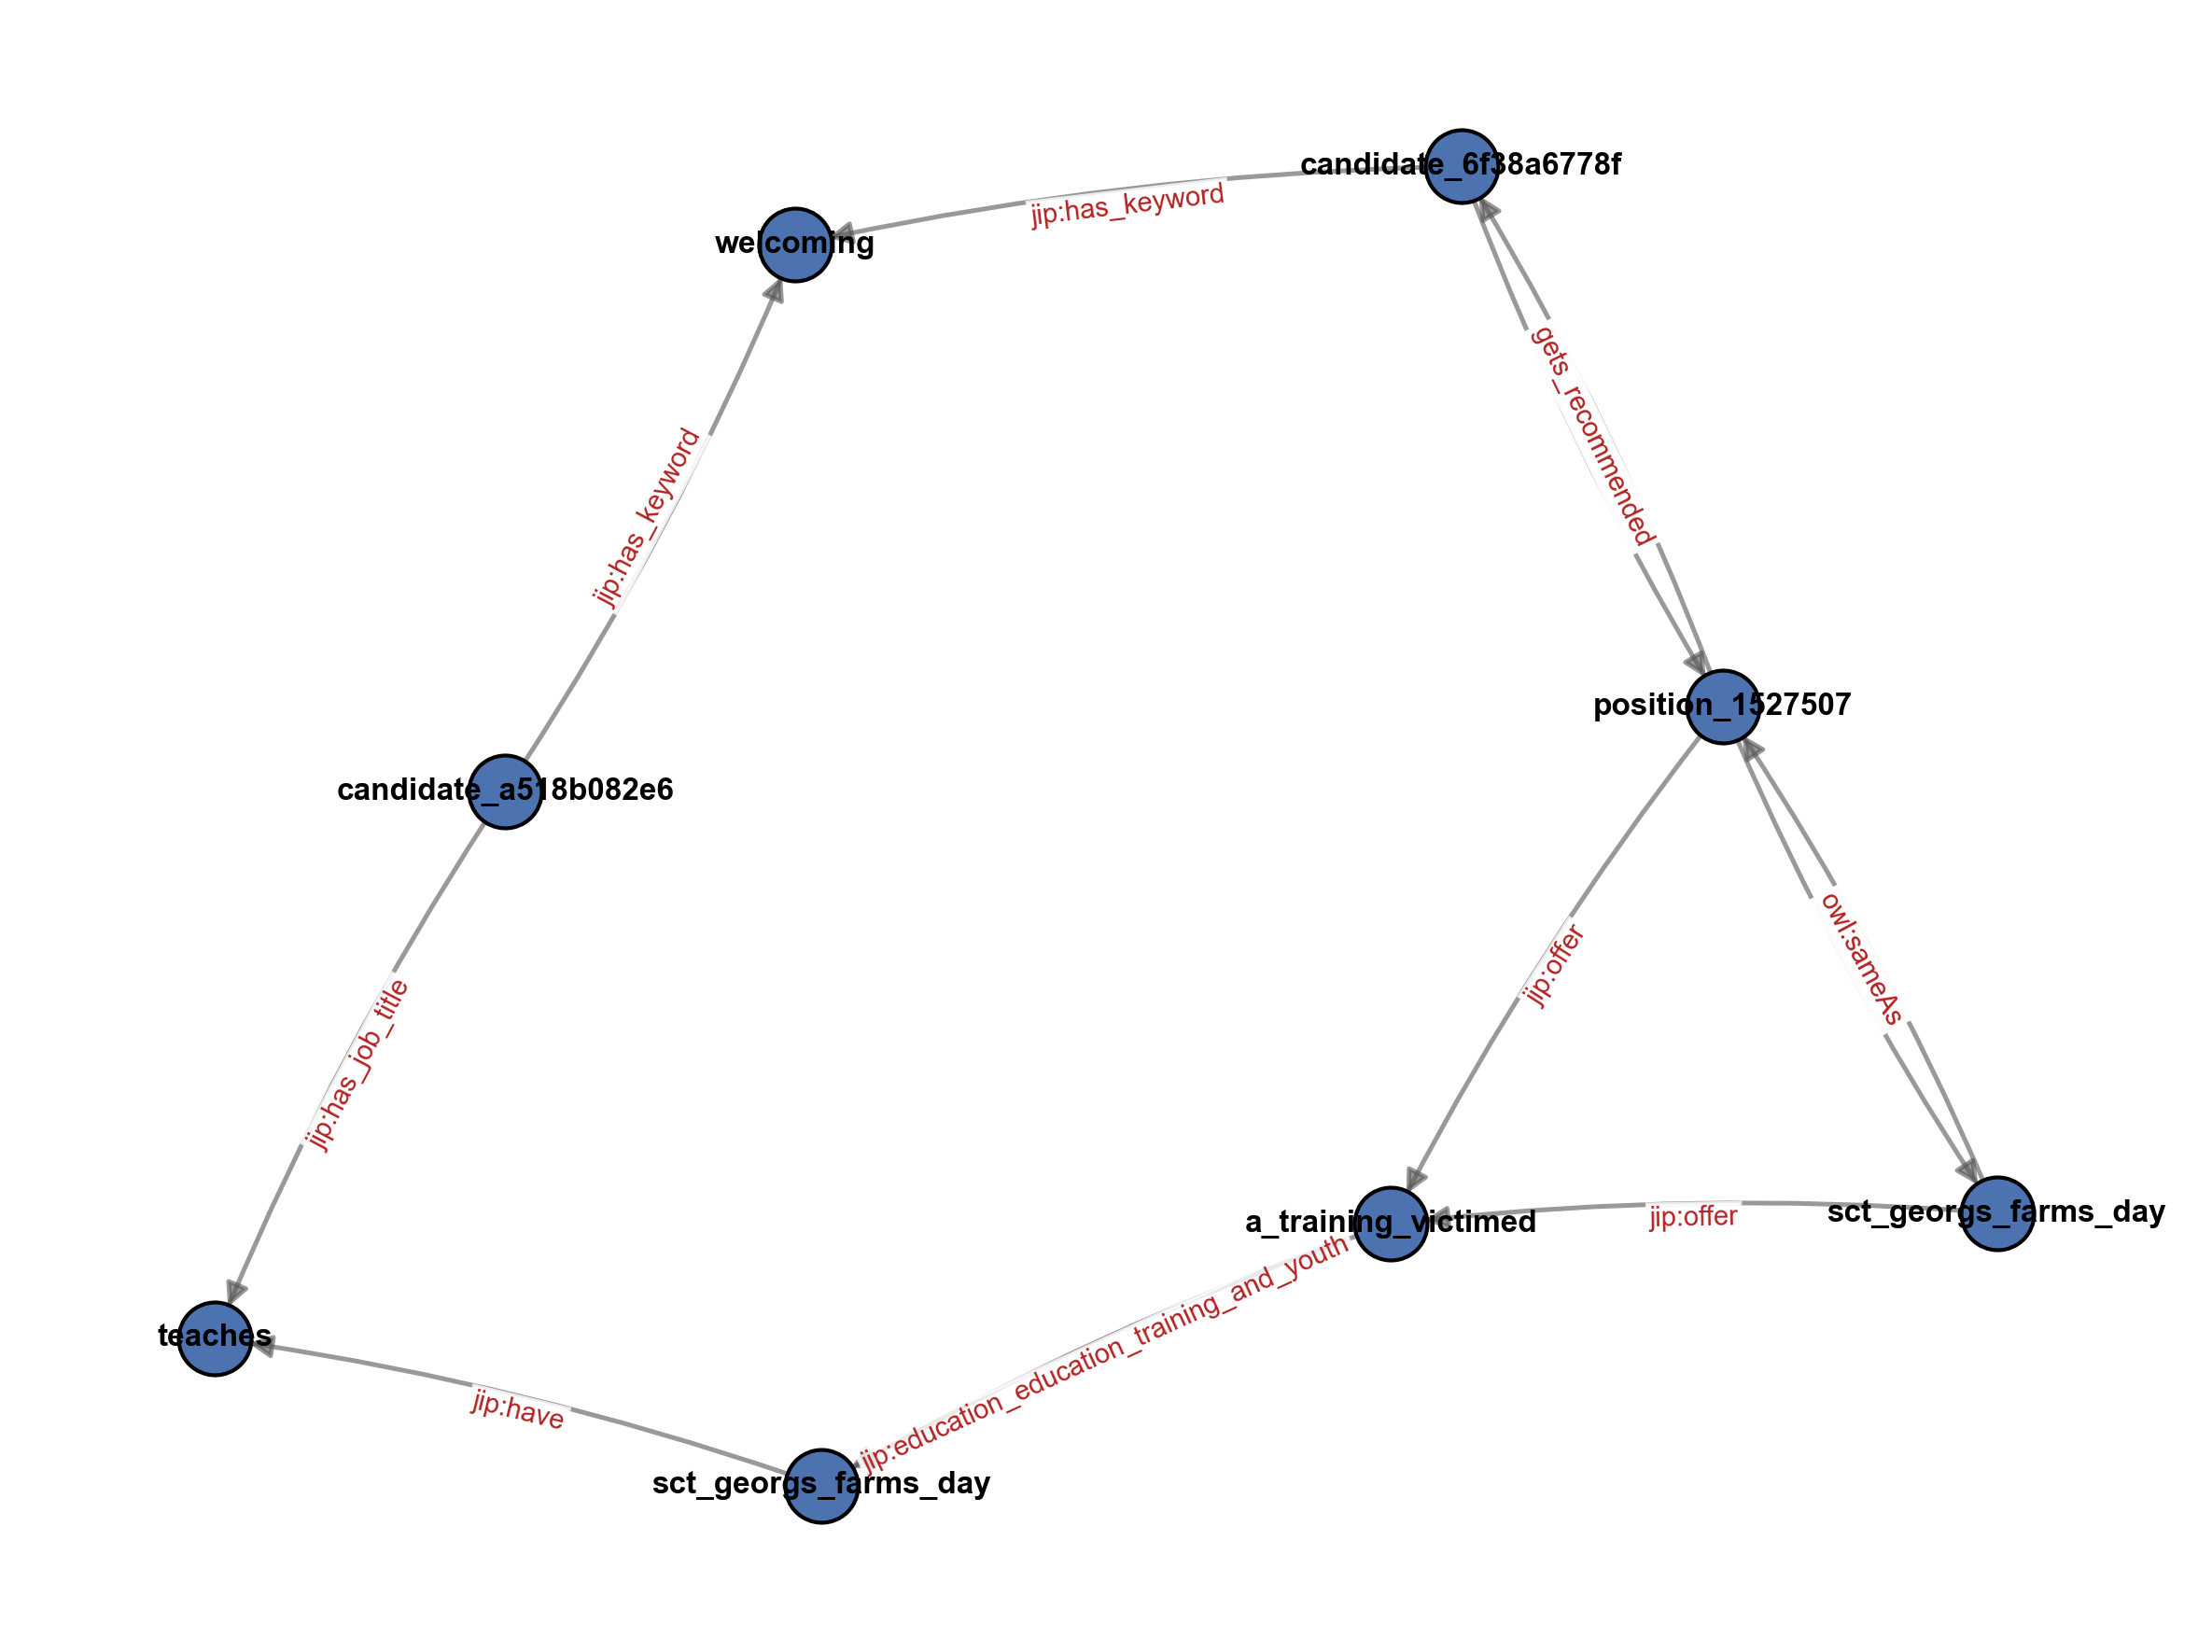

In [8]:
def plot_clean_graph(G, output_filename="sub_graph_with_inference.pdf"):
    # 0. SET PUBLICATION PARAMETERS
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'figure.dpi': 300 
    })
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # 1. REMOVE SELF-LOOPS
    display_G = G.copy()
    display_G.remove_edges_from(nx.selfloop_edges(display_G))
    
    # 2. POSITIONAL LAYOUT
    pos = nx.kamada_kawai_layout(display_G)
    
    # 3. DRAW NODES
    nx.draw_networkx_nodes(
        display_G, pos,
        ax=ax,
        node_size=350,
        node_color='#4C72B0',
        edgecolors='black',
        linewidths=1.0
    )
    
    # 4. DRAW EDGES
    nx.draw_networkx_edges(
        display_G, pos,
        ax=ax,
        alpha=0.6,
        edge_color='#555555',
        arrows=True,
        arrowsize=12,
        arrowstyle='-|>',
        width=1.2,
        connectionstyle='arc3,rad=0.05' 
    )
    
    # 4.5 DRAW EDGE LABELS
    # IMPORTANT: Change 'label' to whatever key your edge data uses (e.g., 'weight', 'relation')
    edge_labels = nx.get_edge_attributes(display_G, 'edge_type')
    
    nx.draw_networkx_edge_labels(
        display_G, pos,
        edge_labels=edge_labels,
        ax=ax,
        font_size=7,
        font_color='#B22222', # Dark red to stand out from nodes/edges
        bbox=dict(alpha=0.8, color='white', edgecolor='none', pad=0.5) # White background so lines don't obscure text
    )
    
    # 5. CLEAN LABELS
    labels = {n: str(n).replace("jie:", "").replace("_jie_", "").split('/')[-1][:20] 
              for n in display_G.nodes()}
    
    nx.draw_networkx_labels(
        display_G, pos, labels,
        ax=ax,
        font_size=8,
        font_weight='bold',
        font_color='black'
    )
    
    # 6. FINALIZE & EXPORT
    ax.axis('off')
    plt.tight_layout() 
    
    plt.savefig(output_filename, format='pdf', bbox_inches='tight', dpi=300)
    plt.show()
    
    
plot_clean_graph(json_graph.node_link_graph(df_sgs.iloc[1]["graph"]))

C:\Users\roans\anaconda3.0\envs\transformers\lib\site-packages\networkx\readwrite\json_graph\node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(
C:\Users\roans\anaconda3.0\envs\transformers\lib\site-packages\networkx\drawing\nx_pylab.py:1375: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  super().__init__(self.x, self.y, *args, rotation=self.angle, **kwargs)


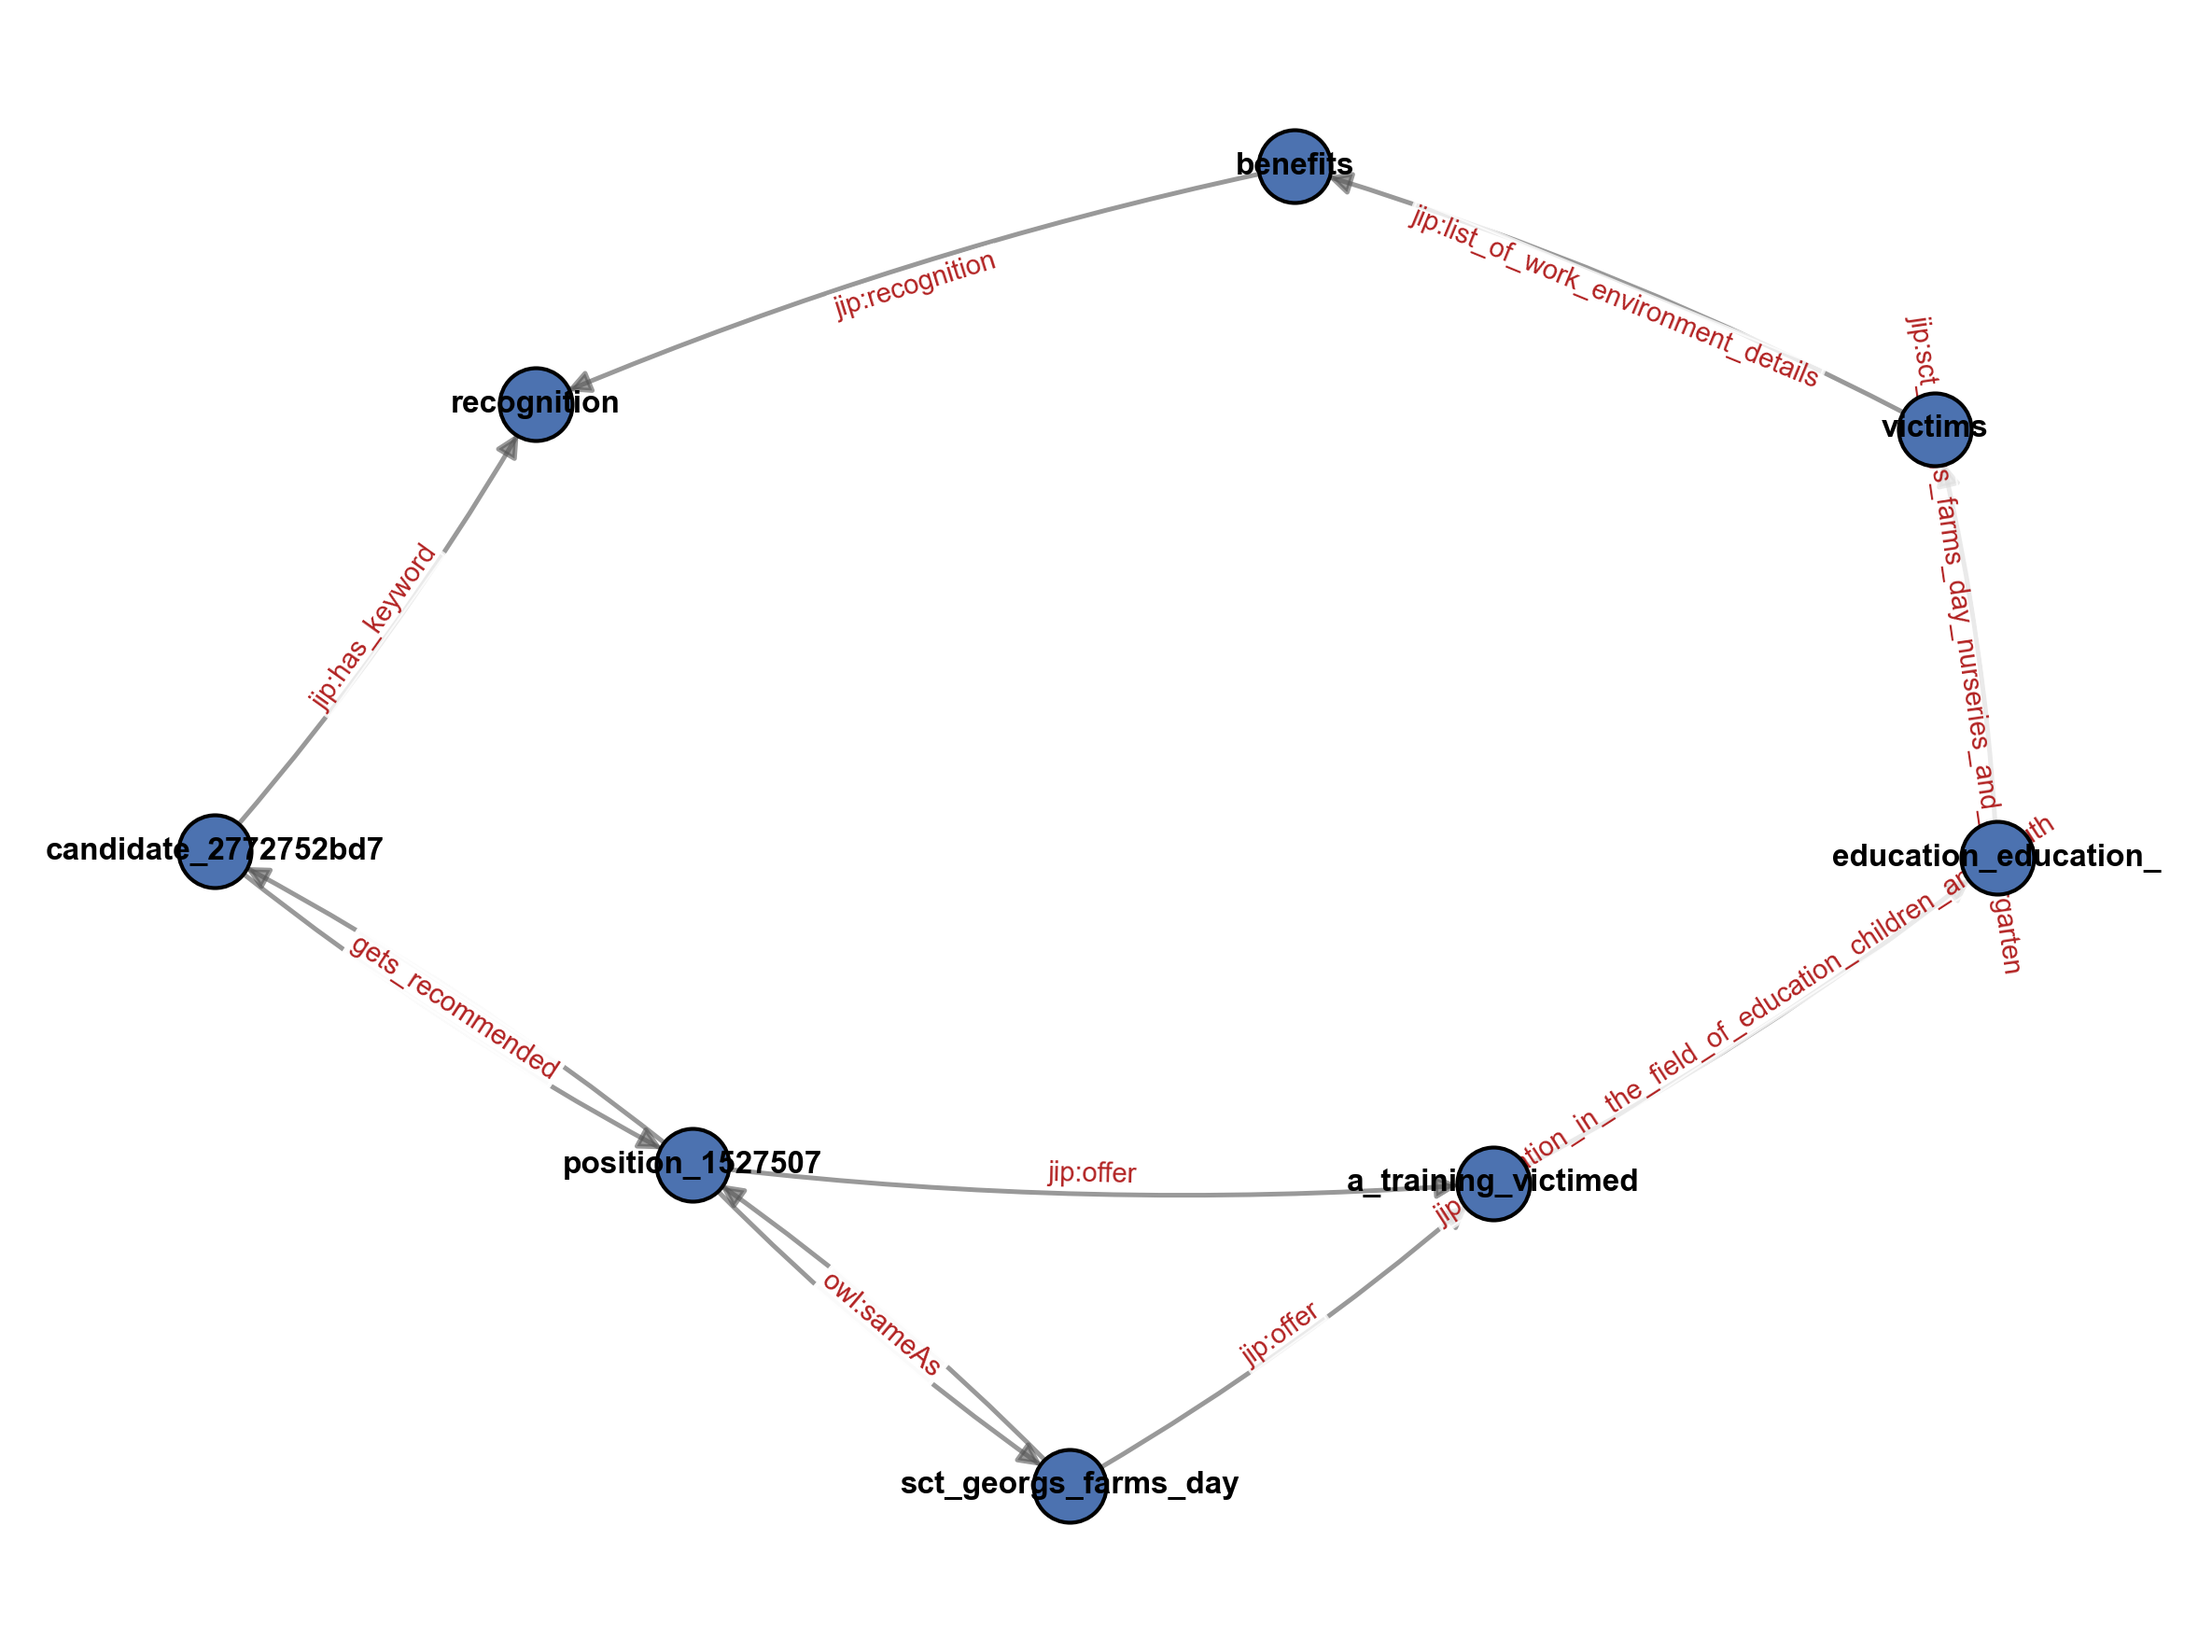

In [9]:
plot_clean_graph(json_graph.node_link_graph(df_sgs.iloc[4]["graph"]))